**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 2](#toc1_)    
  - [Before Starting](#toc1_1_)    
  - [Introduction](#toc1_2_)    
  - [**1. Data Preparation**](#toc1_3_)    
  - [**1.1 Load data**](#toc1_4_)    
    - [**1.2 Save data**](#toc1_4_1_)    
  - [**2. Large Language Models (LLMs)**](#toc1_5_)    
    - [Open-Source vs. Proprietary LLMs](#toc1_5_1_)    
    - [Why Use Code (API) for Data Mining?](#toc1_5_2_)    
    - [The Gemini API](#toc1_5_3_)    
    - [Interacting with the Gemini API](#toc1_5_4_)    
    - [**2.1 Text Prompting**](#toc1_5_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_5_1_1_)    
    - [**2.2 Structured Output**](#toc1_5_6_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_5_6_1_1_)    
    - [**2.3 Information Extraction and Grounding:**](#toc1_5_7_)    
      - [**`langextract`: A Library for Grounded Extraction**](#toc1_5_7_1_)    
        - [**2.3.1 Using PDF Documents:**](#toc1_5_7_1_1_)    
        - [**>>> Bonus Exercise 3 (Take home):**](#toc1_5_7_1_2_)    
    - [**2.4 Generating LLM Embeddings:**](#toc1_5_8_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_5_8_1_1_)    
    - [**2.5 Retrieval-Augmented Generation (RAG)**](#toc1_5_9_)    
        - [**Actual answer in the URL:**](#toc1_5_9_1_1_)    
        - [**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc1_5_9_1_2_)    
        - [**>>> Bonus Exercise 5 (Take home):**](#toc1_5_9_1_3_)    
    - [**2.6 Few-Shot Prompting Classification:**](#toc1_5_10_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_5_10_1_1_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_5_10_1_2_)    
    - [**2.7 Extra LLM Related Materials:**](#toc1_5_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 2](#toc0_)
In this lab's phase 2 session we will focus on exploring some basic LLMs' applications with data.


## <a id='toc1_1_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

---
## <a id='toc1_2_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

---
## <a id='toc1_3_'></a>[**1. Data Preparation**](#toc0_)

---
## <a id='toc1_4_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [1]:
import pandas as pd

### training data
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                         sep="\t", header=None,names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

In [2]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [3]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

,id,text,emotion,intensity
0,10000,How the fu*k! Who the heck! moved my fridge!.....,anger,0.938
1,10001,So my Indian Uber driver just called someone t...,anger,0.896
2,10002,@DPD_UK I asked for my parcel to be delivered ...,anger,0.896
3,10003,so ef whichever butt wipe pulled the fire alar...,anger,0.896
4,10004,Don't join @BTCare they put the phone down on ...,anger,0.896


In [4]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [5]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

Shape of Training df:  (3613, 4)
Shape of Testing df:  (347, 4)


---
### <a id='toc1_4_1_'></a>[**1.2 Save data**](#toc0_)

In [6]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [7]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
## <a id='toc1_5_'></a>[**2. Large Language Models (LLMs)**](#toc0_)

Before we start we strongly suggest that you watch the following video explanations so you can understand the concepts that we are gonna discuss about LLMs: 

1. [How Large Language Models Work](https://www.youtube.com/watch?v=5sLYAQS9sWQ)
2. [Large Language Models explained briefly](https://www.youtube.com/watch?v=LPZh9BOjkQs)
3. [What is Prompt Tuning?](https://www.youtube.com/watch?v=yu27PWzJI_Y)
4. [Why Large Language Models Hallucinate](https://www.youtube.com/watch?v=cfqtFvWOfg0)
5. [What are LLM Embeddings?](https://www.youtube.com/watch?v=UShw_1NbpCw&t=182s)
6. [What is Retrieval-Augmented Generation (RAG)?](https://www.youtube.com/watch?v=T-D1OfcDW1M)
7. [RAG vs Fine-Tuning vs Prompt Engineering: Optimizing AI Models](https://www.youtube.com/watch?v=zYGDpG-pTho)
8. [Discover Few-Shot Prompting | Google AI Essentials](https://www.youtube.com/watch?v=9qdgEBVkWR4)
9. [What is Zero-Shot Learning?](https://www.youtube.com/watch?v=pVpr4GYLzAo)
10. [Zero-shot, One-shot and Few-shot Prompting Explained | Prompt Engineering 101](https://www.youtube.com/watch?v=sW5xoicq5TY)

`These videos can help you get a better grasp on the core concepts of LLMs if you were not familiar before.`

**So now let's start with the main content of Lab 2 Phase 2.**

Large Language Models (LLMs) are AI systems trained on vast amounts of text to understand and generate human language for tasks like summarization and translation.

### <a id='toc1_5_1_'></a>[Open-Source vs. Proprietary LLMs](#toc0_)
*   **Open-Source Models** (e.g., Llama, Gemma) are customizable and cost-effective but require technical skill to manage and may be less powerful.
*   **Proprietary Models** (e.g., Gemini, ChatGPT) offer top performance and ease of use but are more costly and less flexible.

For students interested in running models locally, the optional notebook `DM2025-Lab2-Optional-Ollama.ipynb` explores using Ollama ([Ollama GitHub Link](https://github.com/ollama/ollama)). It needs a capable GPU to run models (**at least 4GB VRAM**).

You can explore the variety of models available through Ollama here:

![pic10.png](./pics/pic10.png)

### <a id='toc1_5_2_'></a>[Why Use Code (API) for Data Mining?](#toc0_)

For data analysis, accessing LLMs programmatically is superior to using web chatbots because it allows for:
*   **Automation:** Easily process entire datasets with loops.
*   **Structured Output:** Receive data in usable formats like **JSON**, ready for analysis in tools like pandas.
*   **Reproducibility:** Ensure consistent results by setting fixed parameters.
*   **Privacy:** Maintain data security, especially when running models locally.

For the main exercises in this lab, we will use **the Gemini API**. This approach offers several advantages over running local open-source models, such as access to state-of-the-art model performance without needing specialized hardware. While the API has usage limits (rate limits and token quotas), it provides a generous **free tier** that is more than sufficient for our exercises.

![pic13.png](./pics/pic13.png)

![pic14.png](./pics/pic14.png)

### <a id='toc1_5_3_'></a>[The Gemini API](#toc0_)

We will primarily use the **Gemini 2.5 Flash-Lite** (`gemini-2.5-flash-lite`) model. As shown in the rate limit table, this model is optimized for high-frequency tasks and offers a high request-per-day limit of 1,000, making it ideal for completing the lab exercises without interruption.

Students are encouraged to explore other models available through the API but should remain mindful of their respective usage limits. For instance:
*   **Gemini 2.5 Pro** is a more powerful model but has a lower daily request limit of 100.
*   The **Gemma 3** model available via the API offers an impressive 14,400 requests per day, providing another excellent alternative for experimentation.

Please be aware of your usage limits as you work through the exercises to ensure you do not get rate-limited.

[Gemini Documentation](https://ai.google.dev/gemini-api/docs)

[Gemini Rate Limits](https://ai.google.dev/gemini-api/docs/rate-limits)

[Description of Gemini Models](https://ai.google.dev/gemini-api/docs/models)

---

### <a id='toc1_5_4_'></a>[Interacting with the Gemini API](#toc0_)

The code cell below contains the primary function, `prompt_gemini`, that we will use throughout this lab to communicate with the Gemini API. It's designed to be a flexible wrapper that handles the details of sending a request and receiving a response.

Before you run the exercises, here are the key things you need to understand in this setup:

*   **API Key Configuration**: The script loads your API key from a `.env` file located in the `./config/` directory. **You must create this file and add your API key** like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`. This is a security best practice to keep your credentials out of the code.

*   **Global Settings**: At the top of the script, you can find and modify several important defaults:
    *   `MODEL_NAME`: We've set this to `"gemini-2.5-flash-lite"`, but you can easily switch to other models like `"gemini-2.5-pro"` to experiment.
    *   `SYSTEM_INSTRUCTION`: This sets the model's default behavior or persona (e.g., "You are a helpful assistant"). You can customize this for different tasks.
    *   `SAFETY_SETTINGS`: For our academic exercises, these are turned off to prevent interference. In real-world applications, you would configure these carefully.

*   **The `prompt_gemini` function**: This is the main tool you will use. Here are its most important parameters:
    *   `input_prompt`: The list of contents (text, images, etc.) you want to send to the model.
    *   `temperature`: Controls the randomness of the output. `0.0` makes the output deterministic and less creative, while a higher value (e.g., `0.7`) makes it more varied.
    *   `schema`: A powerful feature that allows you to specify a JSON format for the model's output. This is extremely useful for structured data extraction.
    *   `with_tokens_info`: If set to `True`, the function will also return the number of input and output tokens used, which is helpful for monitoring your usage against the free tier limits.

In the following exercises, you will call this function with different prompts and configurations to solve various tasks.

If needed, you can also check some tutorials on how a python function works: [Python Functions Tutorial](https://realpython.com/defining-your-own-python-function/)

In [13]:
import os
from dotenv import load_dotenv
from google import genai
from google.genai import types

env_path = "./config/.env"
load_dotenv(dotenv_path=env_path)

# System instruction that can dictate how the model behaves in the output, can be customized as needed
SYSTEM_INSTRUCTION = (
        "You are a helpful assistant"
    )

# Max amount of tokens that the model can output, the Gemini 2.5 Models have this maximum amount
# For other models need to check their documentation 
MAX_OUTPUT_TOKENS = 65535
MODEL_NAME = "gemini-2.5-flash-lite" # Other models: "gemini-2.5-pro", "gemini-2.5-flash"; Check different max output tokens: "gemini-2.0-flash" , "gemini-2.0-flash-lite" 

# We disable the safety settings, as no moderation is needed in our tasks
SAFETY_SETTINGS = [
    types.SafetySetting(
        category="HARM_CATEGORY_HATE_SPEECH", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_SEXUALLY_EXPLICIT", threshold="OFF"),
    types.SafetySetting(
        category="HARM_CATEGORY_HARASSMENT", threshold="OFF")
]

#IMPORTANT: The script loads your API key from a `.env` file located in the `./config/` directory. 
# You must create this file and add your API key like this: `GOOGLE_API_KEY='YOUR_API_KEY_HERE'`

# We input the API Key to be able to use the Gemini models
api_key = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_KEY"] = api_key
client = genai.Client(api_key=api_key)

# We also set LangExtract to use the API key as well:
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = api_key

def prompt_gemini(
        input_prompt: list,
        schema = None,
        temperature: float = 0.0,
        system_instruction: str = SYSTEM_INSTRUCTION,
        max_output_tokens: int = MAX_OUTPUT_TOKENS,
        client: genai.Client = client,
        model_name: str = MODEL_NAME,
        new_config: types.GenerateContentConfig = None,
        with_tools: bool = False,
        with_parts: bool = False,
        with_tokens_info: bool = False
    ):
        try:
            # If we need a JSON schema we set up the following
            if schema:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    response_mime_type="application/json",
                    response_schema=schema,
                    safety_settings=SAFETY_SETTINGS
                )
            # If there is no need we leave it unstructured
            else:
                generate_content_config = types.GenerateContentConfig(
                    temperature=temperature,
                    system_instruction=system_instruction,
                    max_output_tokens=max_output_tokens,
                    response_modalities=["TEXT"],
                    safety_settings=SAFETY_SETTINGS
                )
            
            # We add a different custom configuration if we need it
            if new_config:
                generate_content_config = new_config
            
            # For some tasks we need a more specific way to add the contents when prompting the model
            # So we need custom parts for it sometimes from the "types" objects
            if with_parts:
                response = client.models.generate_content(
                    model=model_name,
                    contents=types.Content(parts=input_prompt),
                    config=generate_content_config,
                )
            # In the simplest form the contents can be expressed as a list [] of simple objects like str and Pillow images
            else:
                response = client.models.generate_content(
                    model=model_name,
                    contents=input_prompt,
                    config=generate_content_config,
                )

            if with_tools:
                # print(response)
                # Include raw response when function calling
                completion = response
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    return completion, log
                return completion
            else:
                completion = response.text
                if with_tokens_info:
                    log = {
                        "model": model_name,
                        "input_tokens": response.usage_metadata.prompt_token_count,
                        "output_tokens": response.usage_metadata.candidates_token_count,
                    }
                    # Return the text response and logs (if selected)
                    return completion, log
                return completion
        except Exception as e:
             print(f"Error occurred when generating response, error: {e}")
             return None

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


---
### <a id='toc1_5_5_'></a>[**2.1 Text Prompting**](#toc0_)

In the same way as with ChatGPT we can use the Gemini models to ask about anything. Here we are going to ask a question requesting the response to be in markdown format, this is to make it have a better display afterwards.

For more information visit:
[Gemini's Text Generation Documentation](https://ai.google.dev/gemini-api/docs/text-generation)

In [14]:
input_prompt = ["What is Data Mining?"]
text_response, logs = prompt_gemini(input_prompt = input_prompt, with_tokens_info = True)
print(text_response)

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strat

We can also check the logs of the usage with our model that we defined in our previous function. We can observe the model we used, how many tokens where in the prompt in the input, and the output text response tokens of our model.

In [15]:
print(logs)

{'model': 'gemini-2.5-flash-lite', 'input_tokens': 12, 'output_tokens': 911}


**We can use the IPython library to make the response look better:**

In [16]:
from IPython.display import display, Markdown
display(Markdown(text_response))

Data mining is the process of **discovering patterns, insights, and knowledge from large datasets**. It's essentially about extracting valuable information that isn't immediately obvious from raw data. Think of it as sifting through a mountain of information to find hidden gems.

Here's a breakdown of what that means:

**Key Concepts:**

*   **Large Datasets:** Data mining is typically applied to datasets that are too large and complex for manual analysis. This can include customer transaction records, website logs, sensor data, social media feeds, scientific experiment results, and much more.
*   **Patterns and Insights:** The goal is to identify recurring trends, correlations, anomalies, and relationships within the data. These patterns can reveal underlying structures, predict future behavior, or explain observed phenomena.
*   **Knowledge Discovery:** The ultimate aim is to transform raw data into actionable knowledge that can be used for decision-making, problem-solving, and strategic planning.

**How it Works (The Process):**

Data mining is usually an iterative process that involves several stages:

1.  **Business Understanding:** Defining the problem or objective you want to achieve with data mining. What questions are you trying to answer? What business goals are you trying to meet?
2.  **Data Understanding:** Exploring and getting familiar with the data. This involves collecting, cleaning, and understanding the data's structure, quality, and meaning.
3.  **Data Preparation (Preprocessing):** This is often the most time-consuming stage. It involves:
    *   **Cleaning:** Handling missing values, noisy data, and inconsistencies.
    *   **Integration:** Combining data from multiple sources.
    *   **Transformation:** Normalizing or aggregating data to make it suitable for mining.
    *   **Reduction:** Reducing the size of the dataset while preserving important information.
4.  **Modeling:** Selecting and applying appropriate data mining techniques (algorithms) to discover patterns. This is where the "mining" happens.
5.  **Evaluation:** Assessing the quality and usefulness of the discovered patterns. Do they make sense? Are they statistically significant? Do they meet the business objectives?
6.  **Deployment:** Putting the discovered knowledge into practice. This could involve integrating it into business processes, creating reports, or building predictive models.

**Common Data Mining Techniques:**

Data mining employs a variety of techniques, often drawing from statistics, machine learning, and database systems. Some of the most common include:

*   **Classification:** Categorizing data into predefined classes (e.g., predicting whether a customer will churn or not).
*   **Clustering:** Grouping similar data points together without predefined classes (e.g., segmenting customers into different groups based on their purchasing behavior).
*   **Association Rule Mining:** Discovering relationships between items in a dataset (e.g., "customers who buy bread also tend to buy milk"). This is often used in market basket analysis.
*   **Regression:** Predicting a continuous numerical value (e.g., predicting the price of a house based on its features).
*   **Anomaly Detection (Outlier Detection):** Identifying data points that deviate significantly from the norm (e.g., detecting fraudulent transactions).
*   **Sequential Pattern Mining:** Discovering patterns that occur in a sequence over time (e.g., identifying common user navigation paths on a website).

**Why is Data Mining Important?**

Data mining is crucial for businesses and organizations because it enables them to:

*   **Make Better Decisions:** By understanding customer behavior, market trends, and operational efficiencies, organizations can make more informed and strategic decisions.
*   **Improve Customer Relationships:** Identifying customer preferences and predicting their needs allows for personalized marketing, better customer service, and increased loyalty.
*   **Detect Fraud and Risk:** Anomaly detection can help identify fraudulent activities, security breaches, and potential risks.
*   **Optimize Operations:** Understanding patterns in operational data can lead to improved efficiency, reduced costs, and better resource allocation.
*   **Drive Innovation:** Discovering new insights can spark new product development, service offerings, and business models.
*   **Gain a Competitive Advantage:** Organizations that effectively leverage data mining can outperform their competitors by understanding their market and customers better.

In essence, data mining is a powerful tool for transforming raw data into valuable intelligence, driving progress and innovation across various fields.

---
##### <a id='toc1_5_5_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)

`With your own prompt`, run the previous example in the following way:

1. Run it with the same model as the example (gemini-2.5-flash-lite). 
2. Run it with a different gemini model from the available options for the API.
3. Discuss the differences on the results with different models.
4. Discuss what would happen if you change the system prompt.


In [ ]:

import os
from dotenv import load_dotenv
from google import genai
from google.genai import types


load_dotenv("./config/.env")
api_key = os.getenv("GOOGLE_API_KEY")
if api_key is None:
    raise ValueError(" 找不到 GOOGLE_API_KEY，請確認 config/.env 是否存在且內容正確")


client = genai.Client(api_key=api_key)


def prompt_gemini(input_prompt, model, safety_settings=None, with_tokens_info=False):
    response = client.models.generate_content(
        model=model,
        contents=input_prompt,
        config=types.GenerateContentConfig(
            safety_settings=safety_settings
        )
    )
    text = response.text
    logs = response.usage_metadata if with_tokens_info else None
    return text, logs


SAFETY_SETTINGS = None


query = ["What is Data Mining in simple terms?"]

 
model_A = "gemini-2.0-flash"
model_B = "gemini-2.5-pro"


text1, log1 = prompt_gemini(
    input_prompt=query,
    model=model_A,
    safety_settings=SAFETY_SETTINGS,
    with_tokens_info=True
)

print("Model A 回覆（gemini-2.0-flash")
print(text1)
print("Tokens:", log1)


text2, log2 = prompt_gemini(
    input_prompt=query,
    model=model_B,
    safety_settings=SAFETY_SETTINGS,
    with_tokens_info=True
)

print("\n Model B 回覆（gemini-2.5-pro）")
print(text2)
print("Tokens:", log2)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


=== Model A 回覆（gemini-2.0-flash） ===
Imagine you have a giant pile of LEGO bricks.

**Data mining is like sifting through that pile to find hidden patterns and interesting information.**

Instead of LEGOs, you're looking through lots of data (like customer transactions, website clicks, or survey responses). You're using special tools and techniques to find things like:

*   **What colors are most often used together in buildings?** (Finding associations)
*   **Which customer is most likely to buy a certain set?** (Making predictions)
*   **Are there any unusually large bricks in the pile?** (Detecting anomalies)
*   **Can you group the bricks into different sets?** (clustering)

**Basically, data mining is about discovering knowledge and insights from large amounts of data to help make better decisions.**

Tokens: cache_tokens_details=None cached_content_token_count=None candidates_token_count=168 candidates_tokens_details=[ModalityTokenCount(
  modality=<MediaModality.TEXT: 'TEXT'>,
 

In [ ]:
'''3. 不同模型輸出結果的差億討論

從兩個模型的回答可以看出以下差異：

(1) 回答內容的深度的不同

gemini-2.0-flash 的回答較簡短且直觀，用 LEGO 的比喻快速說明重點。

gemini-2.5-pro 的回答明顯更長，內容更完整，會進一步補充概念、舉例與說明。

(2) 推理與語言表達能力差異

flash 偏向「快速給出簡單答案，語言較口語化。

pro 則會產生「更接近教科書式」的說明，邏輯推理較強，內容組織更清楚。

(3) Token 使用量差異

flash 模型 token 用量較少:輕量、快速。

pro 模型 token 顯著較多:表示提供了更多敘述、推論與背景知識。

4. 若改變 system prompt 會發生什麼？

更改 system prompt 會直接影響模型回答的風格、深度、角度與語氣：

(1) 回答風格會改變

例如：

system prompt 要求簡單:回答會更精簡。

system prompt 要求專業:回答會更正式、技術化。

(2) 回答內容方向會改變

如果 system prompt 指定角色，模型會用該角色的視角解釋問題。'''

'3. 不同模型輸出結果的差異討論\n\n從兩個模型的回答可以看出以下差異：\n\n(1) 回答內容的深度不同\n\ngemini-2.0-flash 的回答較簡短、直觀，用 LEGO 的比喻快速說明重點。\n\ngemini-2.5-pro 的回答明顯更長，內容更完整，會進一步補充概念、舉例與說明。\n\n(2) 推理與語言表達能力差異\n\nflash 偏向「快速給出簡單答案」，語言較口語化。\n\npro 則會產生「更接近教科書式」的說明，邏輯推理較強，內容組織更清楚。\n\n(3) Token 使用量差異\n\nflash 模型 token 用量較少 → 輕量、快速。\n\npro 模型 token 顯著較多 → 表示提供了更多敘述、推論與背景知識。\n\n4. 若改變 system prompt 會發生什麼？\n\n更改 system prompt 會直接影響模型回答的風格、深度、角度與語氣：\n\n(1) 回答風格會改變\n\n例如：\n\nsystem prompt 要求簡單 → 回答會更精簡。\n\nsystem prompt 要求專業 → 回答會更正式、技術化。\n\n(2) 回答內容方向會改變\n\n如果 system prompt 指定角色（如「你是一位資料科學家」），模型會用該角色的視角解釋問題。'

---
### <a id='toc1_5_6_'></a>[**2.2 Structured Output**](#toc0_)

By default, an LLM responds with unstructured, free-form text. For data mining, this is often impractical, as we need data in a predictable format to load into tools like a pandas DataFrame for analysis. **Structured output** is a powerful feature that forces the model to return its response in a specific, machine-readable format, such as JSON.

The key to enabling this is to provide the model with a **response schema**. This schema acts as a strict template or blueprint that the model's output must conform to. Instead of generating a paragraph, the model will fill in the fields defined in your schema with the relevant information it extracts from the prompt.

In the following code, we define this schema using Python classes. Think of each class as defining a JSON object:
*   The **attributes** of the class (e.g., `topic_name`, `sub_title`) become the keys in the final JSON object.
*   The **type hints** for those attributes (e.g., `str`, `list`) tell the model what kind of data is expected for each key's value.

We can even nest these classes inside one another to create complex, hierarchical JSON structures. This allows us to precisely control the format of the output, transforming the LLM from a simple text generator into a reliable tool for automated and structured data extraction.

[Gemini's Structured Output Documentation](https://ai.google.dev/gemini-api/docs/structured-output)

For data validation of schemas Gemini API uses the Pydantic library, for more documentation on it you can check: [Pydantic](https://docs.pydantic.dev/latest/) 

[JSON Format Documentation](https://docs.python.org/3/library/json.html)

In [21]:
from pydantic import BaseModel

# We define our structure schema that Gemini should follow for the output response

# Subsections on the topics we query
class Subsection(BaseModel):
    sub_title: str
    sub_explanation: str

# The top-level structure for the entire topic analysis
class Topic(BaseModel):
    topic_name: str
    subsections: list[Subsection]

In [ ]:

def prompt_gemini(input_prompt, model, safety_settings=None, schema=None, with_tokens_info=False):

    gen_config = types.GenerateContentConfig(
        safety_settings=safety_settings
    )

    if schema is not None:
        gen_config.response_schema = schema

  
    response = client.models.generate_content(
        model=model,
        contents=input_prompt,
        config=gen_config
    )

    
    text = response.text
    logs = response.usage_metadata if with_tokens_info else None
    return text, logs
from typing_extensions import TypedDict

class Topic(TypedDict):
    machine_learning: str
    data_centers: str
    llms: str
    relationship: str

schema = Topic  

input_prompt = [
    "Explain what are machine learning, data centers, LLMs and how they relate to each other."
]

text_response, _ = prompt_gemini(
    input_prompt=input_prompt,
    model="gemini-2.5-pro",
    schema=schema
)

print(text_response)



Of course! Let's break down these concepts individually and then see how they fit together like pieces of a puzzle.

Think of it this way:
*   **Machine Learning** is the brain's ability to learn a new skill.
*   **A Data Center** is the physical body that provides the power, bones, and blood for the brain to function.
*   **An LLM** is a very specific, highly advanced skill that the brain has learned, like becoming a world-class expert in language.

---

### 1. What is Machine Learning (ML)?

In simple terms, **Machine Learning is a way of teaching computers to find patterns and make decisions from data, without being explicitly programmed for every single task.**

*   **Traditional Programming:** You write hard-coded rules. "If you see the word 'viagra' in an email, mark it as spam." This is brittle; what if the spammer writes "v1agra"?
*   **Machine Learning:** You don't write the rules. Instead, you show the computer thousands of examples of spam emails and thousands of examples of

In [ ]:
import json
import re


def extract_json(text):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        return json.loads(match.group(0))   
    else:
        
        return text

structured_resp = extract_json(text_response)

print(structured_resp)
print(type(structured_resp))


Of course! Let's break down these concepts individually and then see how they fit together like pieces of a puzzle.

Think of it this way:
*   **Machine Learning** is the brain's ability to learn a new skill.
*   **A Data Center** is the physical body that provides the power, bones, and blood for the brain to function.
*   **An LLM** is a very specific, highly advanced skill that the brain has learned, like becoming a world-class expert in language.

---

### 1. What is Machine Learning (ML)?

In simple terms, **Machine Learning is a way of teaching computers to find patterns and make decisions from data, without being explicitly programmed for every single task.**

*   **Traditional Programming:** You write hard-coded rules. "If you see the word 'viagra' in an email, mark it as spam." This is brittle; what if the spammer writes "v1agra"?
*   **Machine Learning:** You don't write the rules. Instead, you show the computer thousands of examples of spam emails and thousands of examples of

In [ ]:

if not isinstance(structured_resp, list):
    print("❗ structured_resp is not a list of topics. Actual value:")
    print(structured_resp)
else:
 
    for topic in structured_resp:
        print(topic.get("topic_name", "No topic_name field"), "\n")

        for subsection in topic.get("subsections", []):
            print("\t", subsection.get("sub_title", "No sub_title"), "\n")
            print("\t\t", subsection.get("sub_explanation", "No explanation"), "\n")


❗ structured_resp is not a list of topics. Actual value:
Of course! Let's break down these concepts individually and then see how they fit together like pieces of a puzzle.

Think of it this way:
*   **Machine Learning** is the brain's ability to learn a new skill.
*   **A Data Center** is the physical body that provides the power, bones, and blood for the brain to function.
*   **An LLM** is a very specific, highly advanced skill that the brain has learned, like becoming a world-class expert in language.

---

### 1. What is Machine Learning (ML)?

In simple terms, **Machine Learning is a way of teaching computers to find patterns and make decisions from data, without being explicitly programmed for every single task.**

*   **Traditional Programming:** You write hard-coded rules. "If you see the word 'viagra' in an email, mark it as spam." This is brittle; what if the spammer writes "v1agra"?
*   **Machine Learning:** You don't write the rules. Instead, you show the computer thousand

##### <a id='toc1_5_6_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)

Try a prompt with your own schema structure, it needs to be completely different to the example. It should show an intuitive way to represent the text output of the model based on the prompt you chose. See the documentation for reference: https://ai.google.dev/gemini-api/docs/structured-output

In [ ]:
import json
import re

def extract_json_block(text):
    cleaned_text = re.sub(r"`{3}(json)?", "", text).strip()
    return json.loads(cleaned_text)

prompt_text = """
Explain Autophagy in cells.

Provide the answer strictly in JSON form following this structure:
{
  "concept": "string",
  "core_functions": ["string"],
  "key_molecules": ["string"],
  "biological_relevance": "string"
}

Rules:
- The response must be valid JSON only
- Begin with { and end with }
- Do not add explanations, comments, or markdown code blocks
"""


reply = client.models.generate_content(
    model="gemini-2.5-pro",
    contents=[prompt_text]
)

print("Model response:\n", reply.text)

json_obj = extract_json_block(reply.text)

print("\nConverted to Python object:")
print(json_obj)


Model response:
 ```json
{
  "concept": "A fundamental catabolic process in eukaryotic cells where cellular components, such as damaged organelles and misfolded proteins, are engulfed in double-membraned vesicles called autophagosomes, which then fuse with lysosomes for degradation and recycling of the contents.",
  "core_functions": [
    "Cellular Quality Control: Removal of damaged organelles, protein aggregates, and intracellular pathogens.",
    "Nutrient Recycling: Providing energy and molecular building blocks during periods of starvation or stress.",
    "Cellular Homeostasis: Maintaining a balance between the synthesis and degradation of cellular components.",
    "Development and Differentiation: Remodeling cells and tissues during organismal development.",
    "Immune Defense: Eliminating intracellular pathogens and contributing to antigen presentation."
  ],
  "key_molecules": [
    "ATG (Autophagy-Related) proteins",
    "ULK1 complex (initiation)",
    "Beclin-1/Vps34 com

---
### <a id='toc1_5_7_'></a>[**2.3 Information Extraction and Grounding:**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

When using LLMs to extract structured data from text, two main challenges arise:

1.  **Trust:** LLMs can "hallucinate" or invent information. We need to ensure the extracted data is accurate and comes directly from the source text.
2.  **Scalability:** We need a reliable way to extract complex information consistently from thousands of large, messy documents.

The solution to these challenges is **grounding**—the process of linking every piece of extracted data back to its specific origin in the source document. This creates a verifiable audit trail, building trust in the output.

---
#### <a id='toc1_5_7_1_'></a>[**`langextract`: A Library for Grounded Extraction**](#toc0_)

**`langextract`** is an open-source Python library from Google designed to create trustworthy data extraction pipelines. It uses LLMs to convert unstructured text into structured data with a focus on reliability and traceability.

**Key Features:**

*   **Precise Grounding:** Its core feature. It maps every extracted item to its exact character position in the original text, allowing for easy verification.
*   **Reliable Structured Output:** Uses examples (few-shot prompting) to ensure the LLM's output consistently follows a predefined format.
*   **Adaptable & No Fine-Tuning:** Can be adapted to any domain (e.g., legal, medical) simply by changing the examples and instructions, without needing to retrain a model.
*   **Handles Long Documents:** Built to process lengthy texts that might exceed an LLM's standard context window.
*   **Flexible LLM Support:** It is model-agnostic and works with various LLMs like Gemini, OpenAI models, and even local open-source models through Ollama.

**`Github repository:`** [langextract](https://github.com/google/langextract)

---

##### <a id='toc1_5_7_1_1_'></a>[**2.3.1 Using PDF Documents:**](#toc0_)

For PDF Document information extraction we are going to use the `pymupdf` library. Documentation: [pymupdf](https://pymupdf.readthedocs.io/en/latest/)

And then we are going to pass it on to langextract to get insights on the document's content.

We can also process documents using Gemini, for more information you can check their documentation: [Document Understanding](https://ai.google.dev/gemini-api/docs/document-processing)

In [42]:
import pymupdf
# Extract text from the PDF and format it for the prompt
# This is a review from the movie interstellar
pdf_path = "./data/documents/doc_example_review_interstellar.pdf"
formatted_text = ""
try:
    doc = pymupdf.open(pdf_path)
    # In case the PDF documents have more than one page, in this example it only has one
    for i, page in enumerate(doc):
        text = page.get_text("text")
        # Format follows the prompt's requirement: **Page X** """document's text"""
        formatted_text += f'**Page {i + 1}**\n'
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'
    doc.close()
    print(f"✓ Extracted text from '{pdf_path}'")
except Exception as e:
    print(f"Could not read PDF: {e}")
    formatted_text = "Error: Could not process PDF file."

✓ Extracted text from './data/documents/doc_example_review_interstellar.pdf'


In [43]:
print(formatted_text)

**Page 1**
"""
Dan Baldwin
Group 4
Auteur Review - Interstellar 
I believe Christopher Nolan: the director behind the 2014 sci-ﬁ/adventure cinematic ‘Interstellar,’ 
to be a very intellectual and imaginative inventive talent.  
His style in his previous ﬁlms sets characters in epic unique locations, with gargantuan issues to 
face, and artistically impresses the audience with how the characters solve their problems. For 
example, in Nolan’s 2010 ﬁlm ‘Inception,’ he tackles the idea of dreams, and sets his characters 
diving through dreams within dreams within even more dreams to complete their goals. Because 
this idea is so farfetched, and dreams are a subject in which science has made little factual 
discovery in, Nolan is free to use his creativity to present ideas such as landscapes folding in on 
themselves and corridors spinning, without seeming unrealistic. 
This brain-racking epic theme is once again evident in ‘Interstellar,’ as Nolan sets his characters 
during a second Ameri

We define our prompt and examples based on our required type of data, in this case we are going to do it having `movie reviews` in mind.

In [45]:
import langextract as lx
import textwrap

# Defining the extraction prompt for "movie review" type of data
prompt = textwrap.dedent("""\
    Extract specific opinions and their impact on the audience from this movie review.
    Important: Use exact text verbatim from the input for extraction_text. Do not paraphrase.
    Extract entities in order of appearance with no overlapping text spans.

    Use the 'opinion_statement' class for direct judgments about film elements (like plot, score, or acting).
    - 'subject' should be the element being reviewed.
    - 'sentiment' should be Positive, Negative, or Neutral.
    - 'key_phrase' should be the core descriptive words.

    Use the 'audience_impact' class for phrases describing the effect on the viewer.
    - 'emotion_evoked' should be the feeling or reaction (e.g., stress, joy, confusion).
    - 'causal_element' is what part of the film caused the reaction.
    - 'target_audience' is who was affected (e.g., 'the audience', 'the reviewer').
    """)

# Providing high-quality examples to guide the model
# These examples show the model exactly how to differentiate between the two classes
examples = [
    # Example 1: Demonstrates a positive opinion on the plot and its direct impact on the reviewer
    lx.data.ExampleData(
        text="The film boasts a truly clever plot that kept me guessing until the very end.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="a truly clever plot",
                attributes={
                    "subject": "The plot",
                    "sentiment": "Positive",
                    "key_phrase": "truly clever"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="kept me guessing until the very end",
                attributes={
                    "emotion_evoked": ["engaged", "curious"],
                    "causal_element": "The plot",
                    "target_audience": "the reviewer"
                }
            ),
        ]
    ),
    # Example 2: Shows a negative opinion and a separate audience impact caused by the soundtrack
    lx.data.ExampleData(
        text="Unfortunately, the dialogue felt clunky and unnatural, and the jarring soundtrack made the audience jump.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="the dialogue felt clunky and unnatural",
                attributes={
                    "subject": "The dialogue",
                    "sentiment": "Negative",
                    "key_phrase": "clunky and unnatural"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="made the audience jump",
                attributes={
                    "emotion_evoked": ["startled", "on edge"],
                    "causal_element": "The soundtrack",
                    "target_audience": "the audience"
                }
            )
        ]
    )
]

Here we define our main function to call for langextract information extraction, note that there are some constants in the functions that we are not going to change for the example but it would be required to explore and understand in the exercise. In this function we obtain the resulting raw extracted information into a .jsonl file and the visualization into a .html file. Check the documentation for more information.

The files will be saved in the following directory: `results/info_extractions`

In [ ]:
import os
import langextract as lx


def grounded_info_extraction(input_documents, prompt, examples, file_name, model_id ="gemini-2.5-flash-lite", extraction_passes = 1, max_workers = 5, max_char_buffer = 2000):
    result = lx.extract(
        text_or_documents=input_documents,
        prompt_description=prompt,
        examples=examples,
        model_id=model_id,
        extraction_passes=extraction_passes, 
        max_workers=max_workers,         
        max_char_buffer=max_char_buffer    
    )

    
    print(f"Extracted {len(result.extractions)} entities:\n")
    for extraction in result.extractions:
        print(f"• {extraction.extraction_class}: '{extraction.extraction_text}'")
        if extraction.attributes:
            for key, value in extraction.attributes.items():
                print(f"  - {key}: {value}")
    
    output_dir = "./results/info_extractions"
    os.makedirs(output_dir, exist_ok=True)
    
    lx.io.save_annotated_documents([result], output_name=f"{file_name}.jsonl", output_dir=output_dir)

    
    html_content = lx.visualize(f"{output_dir}/{file_name}.jsonl")
    with open(f"{output_dir}/{file_name}_vis.html", "w", encoding="utf-8") as f:
        if hasattr(html_content, 'data'):
            f.write(html_content.data)
        else:
            f.write(html_content)

    print(f"✓ Visualization saved to {output_dir}/{file_name}_vis.html")
    
    
    return html_content

In [51]:
html_content = grounded_info_extraction(formatted_text, prompt, examples, "review_extraction_example")

LangExtract: model=gemini-2.5-flash-lite, current=3,199 chars, processed=0 chars:  [00:02]


Extracted 13 entities:

• opinion_statement: 'a very intellectual and imaginative inventive talent'
  - subject: Christopher Nolan
  - sentiment: Positive
  - key_phrase: very intellectual and imaginative inventive talent
• opinion_statement: 'artistically impresses the audience'
  - subject: Nolan's style
  - sentiment: Positive
  - key_phrase: artistically impresses
• opinion_statement: 'This brain-racking epic theme is once again evident in ‘Interstellar,’'
  - subject: The theme
  - sentiment: Positive
  - key_phrase: brain-racking epic theme
• opinion_statement: 'crazy scenarios'
  - subject: Nolan's mind
  - sentiment: Positive
  - key_phrase: crazy
• opinion_statement: 'Not threatening at all right?'
  - subject: The planet
  - sentiment: Neutral
  - key_phrase: Not threatening at all
• opinion_statement: 'a giant 100ft tidal wave is about to hit them'
  - subject: The tidal wave
  - sentiment: Negative
  - key_phrase: giant 100ft tidal wave
• audience_impact: 'minutes to ﬂy awa

LangExtract: Saving to results\info_extractions\review_extraction_example.jsonl: 1 docs [00:00, 128.79 docs/s]

✓ Saved 1 documents to results\info_extractions\review_extraction_example.jsonl



LangExtract: Loading results\info_extractions\review_extraction_example.jsonl: 100%|█████████▉| 8.58k/8.58k [00:00<00:00, 298kB/s]

✓ Loaded 1 documents from results\info_extractions\review_extraction_example.jsonl
✓ Visualization saved to ./results/info_extractions/review_extraction_example_vis.html


In [ ]:
import json

with open("./results/info_extractions/review_extraction_example.jsonl", "r", encoding="utf-8") as f:
    content_extracted_raw = json.load(f)
content_extracted_raw

{'extractions': [{'extraction_class': 'opinion_statement',
   'extraction_text': 'a very intellectual and imaginative inventive talent',
   'char_interval': {'start_pos': 172, 'end_pos': 224},
   'alignment_status': 'match_exact',
   'extraction_index': 1,
   'group_index': 0,
   'description': None,
   'attributes': {'subject': 'Christopher Nolan',
    'sentiment': 'Positive',
    'key_phrase': 'very intellectual and imaginative inventive talent'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'artistically impresses the audience',
   'char_interval': {'start_pos': 338, 'end_pos': 373},
   'alignment_status': 'match_exact',
   'extraction_index': 2,
   'group_index': 1,
   'description': None,
   'attributes': {'subject': "Nolan's style",
    'sentiment': 'Positive',
    'key_phrase': 'artistically impresses'}},
  {'extraction_class': 'opinion_statement',
   'extraction_text': 'This brain-racking epic theme is once again evident in ‘Interstellar,’',
   'char_inter

In [54]:
html_content

---
##### <a id='toc1_5_7_1_2_'></a>[**>>> Bonus Exercise 3 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Repeat the steps for information extraction using a different movie reviews.
1. Search for movie reviews online and save them in a PDF, we suggest **at least 1 page worth of reviews** like in the example.
2. Load the PDF and pass them to langextract to extract information from it.
3. Display html with the grounded extracted attributes.
4. Discuss about the quality of the extracted information with langextract, how could it be improved based on the options the documentation gives that we didn't try?

**`Github repository for reference:`** [langextract](https://github.com/google/langextract)

In [ ]:
import pymupdf


pdf_path = "C:/Users/USER/Downloads/DM2025-Lab2-Exercise-main/DM2025-Lab2-Exercise-main/Here.pdf"

formatted_text = ""

try:
    
    doc = pymupdf.open(pdf_path)

    
    for i, page in enumerate(doc):
        text = page.get_text("text")
        formatted_text += f"**Page {i + 1}**\n"
        formatted_text += f'"""\n{text.strip()}\n"""\n\n'

    doc.close()

except Exception as e:
    
    formatted_text = "Error: Could not process PDF file."


print(formatted_text)


**Page 1**
"""
Here’s a concise English review of Titanic: 
 
Movie Review – Titanic 
Titanic is a timeless blend of historical tragedy and emotional storytelling. James Cameron 
masterfully recreates the grandeur of the ship while grounding the film in the intimate, 
human connection between Jack and Rose. The romance is sincere and captivating, and the 
film’s final act remains one of the most powerful and heartbreaking depictions of 
disaster in cinema. With its iconic soundtrack, impressive visual effects, and unforgettable 
performances, Titanic continues to be a moving and beautifully crafted classic. 
 
If you want it even shorter or more academic, more poetic, or more humorous, I can adjust 
it!
"""




In [ ]:
examples = [

    
    lx.data.ExampleData(
        text="James Cameron masterfully recreates the grandeur of the ship while grounding the film in the intimate, human connection between Jack and Rose.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="masterfully recreates the grandeur of the ship",
                attributes={
                    "subject": "James Cameron / the ship recreation",
                    "sentiment": "Positive",
                    "key_phrase": "masterfully recreates"
                }
            ),
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="intimate, human connection between Jack and Rose",
                attributes={
                    "subject": "Jack and Rose’s relationship",
                    "sentiment": "Positive",
                    "key_phrase": "intimate human connection"
                }
            )
        ]
    ),

    
    lx.data.ExampleData(
        text="The romance is sincere and captivating, and the film’s final act remains one of the most powerful and heartbreaking depictions of disaster in cinema.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="The romance is sincere and captivating",
                attributes={
                    "subject": "The romance",
                    "sentiment": "Positive",
                    "key_phrase": "sincere and captivating"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="one of the most powerful and heartbreaking depictions of disaster",
                attributes={
                    "emotion_evoked": ["sadness", "shock", "deep emotional impact"],
                    "causal_element": "the film’s final act",
                    "target_audience": "the audience"
                }
            )
        ]
    ),

    
    lx.data.ExampleData(
        text="With its iconic soundtrack, impressive visual effects, and unforgettable performances, Titanic continues to be a moving and beautifully crafted classic.",
        extractions=[
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="iconic soundtrack",
                attributes={
                    "subject": "The soundtrack",
                    "sentiment": "Positive",
                    "key_phrase": "iconic"
                }
            ),
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="impressive visual effects",
                attributes={
                    "subject": "Visual effects",
                    "sentiment": "Positive",
                    "key_phrase": "impressive"
                }
            ),
            lx.data.Extraction(
                extraction_class="opinion_statement",
                extraction_text="unforgettable performances",
                attributes={
                    "subject": "Acting performances",
                    "sentiment": "Positive",
                    "key_phrase": "unforgettable"
                }
            ),
            lx.data.Extraction(
                extraction_class="audience_impact",
                extraction_text="Titanic continues to be a moving and beautifully crafted classic",
                attributes={
                    "emotion_evoked": ["deep admiration", "emotional resonance"],
                    "causal_element": "the film's artistic quality",
                    "target_audience": "the viewers"
                }
            )
        ]
    )
]


In [ ]:
import os
import langextract as lx



def run_grounded_extraction(
    documents, 
    task_prompt, 
    example_cases, 
    output_basename,
    model="gemini-2.5-flash-lite",
    passes=1,
    workers=5,
    buffer_size=2000
):
    """
    Perform grounded information extraction using langextract,
    save the results, and generate an HTML visualization.
    """

    extraction_output = lx.extract(
        text_or_documents=documents,
        prompt_description=task_prompt,
        examples=example_cases,
        model_id=model,
        extraction_passes=passes,
        max_workers=workers,
        max_char_buffer=buffer_size
    )

   
    print(f"Total extracted items: {len(extraction_output.extractions)}\n")
    for item in extraction_output.extractions:
        print(f"• {item.extraction_class}: '{item.extraction_text}'")
        if item.attributes:
            for k, v in item.attributes.items():
                print(f"   - {k}: {v}")

    # =========== Save JSONL Output ===========
    save_dir = "./results/info_extraction_outputs"
    os.makedirs(save_dir, exist_ok=True)

    output_path = f"{save_dir}/{output_basename}.jsonl"
    lx.io.save_annotated_documents(
        [extraction_output], 
        output_name=f"{output_basename}.jsonl", 
        output_dir=save_dir
    )

   
    html_vis = lx.visualize(output_path)

    html_file = f"{save_dir}/{output_basename}_visualization.html"
    with open(html_file, "w", encoding="utf-8") as f:
        
        f.write(html_vis.data if hasattr(html_vis, "data") else html_vis)

    print(f"✓ Visualization created: {html_file}")

   
    return html_vis



html_output = run_grounded_extraction(
    documents=formatted_text,
    task_prompt=prompt,
    example_cases=examples,
    output_basename="titanic_extraction_demo"
)



LangExtract: model=gemini-2.5-flash-lite, current=716 chars, processed=0 chars:  [00:04]


Total extracted items: 8

• opinion_statement: 'masterfully recreates the grandeur of the ship'
   - subject: the ship recreation
   - sentiment: Positive
   - key_phrase: masterfully recreates
• opinion_statement: 'intimate, human connection between Jack and Rose'
   - subject: Jack and Rose’s relationship
   - sentiment: Positive
   - key_phrase: intimate human connection
• opinion_statement: 'The romance is sincere and captivating'
   - subject: The romance
   - sentiment: Positive
   - key_phrase: sincere and captivating
• audience_impact: 'one of the most powerful and heartbreaking depictions of disaster'
   - emotion_evoked: ['sadness', 'shock', 'deep emotional impact']
   - causal_element: the film’s final act
   - target_audience: the audience
• opinion_statement: 'iconic soundtrack'
   - subject: The soundtrack
   - sentiment: Positive
   - key_phrase: iconic
• opinion_statement: 'impressive visual effects'
   - subject: Visual effects
   - sentiment: Positive
   - key_phrase:

LangExtract: Saving to results\info_extraction_outputs\titanic_extraction_demo.jsonl: 1 docs [00:00, 391.77 docs/s]

✓ Saved 1 documents to results\info_extraction_outputs\titanic_extraction_demo.jsonl



LangExtract: Loading results\info_extraction_outputs\titanic_extraction_demo.jsonl: 100%|█████████▉| 3.83k/3.83k [00:00<00:00, 165kB/s]

✓ Loaded 1 documents from results\info_extraction_outputs\titanic_extraction_demo.jsonl
✓ Visualization created: ./results/info_extraction_outputs/titanic_extraction_demo_visualization.html


In [ ]:

html_output = run_grounded_extraction(
    documents=formatted_text,
    task_prompt=prompt,
    example_cases=examples,
    output_basename="titanic_review_extraction"
)

html_output


LangExtract: model=gemini-2.5-flash-lite, current=716 chars, processed=0 chars:  [00:03]


Total extracted items: 8

• opinion_statement: 'masterfully recreates the grandeur of the ship'
   - subject: the ship recreation
   - sentiment: Positive
   - key_phrase: masterfully recreates
• opinion_statement: 'intimate, human connection between Jack and Rose'
   - subject: Jack and Rose’s relationship
   - sentiment: Positive
   - key_phrase: intimate human connection
• opinion_statement: 'The romance is sincere and captivating'
   - subject: The romance
   - sentiment: Positive
   - key_phrase: sincere and captivating
• audience_impact: 'one of the most powerful and heartbreaking depictions of disaster'
   - emotion_evoked: ['sadness', 'shock', 'deep emotional impact']
   - causal_element: the film’s final act
   - target_audience: the audience
• opinion_statement: 'iconic soundtrack'
   - subject: The soundtrack
   - sentiment: Positive
   - key_phrase: iconic
• opinion_statement: 'impressive visual effects'
   - subject: Visual effects
   - sentiment: Positive
   - key_phrase:

LangExtract: Saving to results\info_extraction_outputs\titanic_review_extraction.jsonl: 1 docs [00:00, 255.92 docs/s]

✓ Saved 1 documents to results\info_extraction_outputs\titanic_review_extraction.jsonl



LangExtract: Loading results\info_extraction_outputs\titanic_review_extraction.jsonl: 100%|█████████▉| 3.83k/3.83k [00:00<00:00, 190kB/s]

✓ Loaded 1 documents from results\info_extraction_outputs\titanic_review_extraction.jsonl
✓ Visualization created: ./results/info_extraction_outputs/titanic_review_extraction_visualization.html


In [ ]:
'''該文本是 敘事＋情緒＋評論混在一起

許多句子同時包含多個主辭，需要人工分解

情緒用詞有時反映觀眾感受，而非影片優劣

文本內容語意細膩（“moving”, “captivating”），模型容易判斷錯誤語氣

部分形容詞屬於genre描述，而不是 opinion'''

'文本是 敘事＋情緒＋評論混在一起\n\n許多句子同時包含多個主詞，需要人工分解\n\n情緒用詞有時反映觀眾感受，而非影片優劣\n\n文本內容語意細膩（“moving”, “captivating”），模型容易判斷錯誤語氣\n\n部分形容詞屬於 “genre” 描述，而不是 opinion'

---
### <a id='toc1_5_8_'></a>[**2.4 Generating LLM Embeddings:**](#toc0_)

LLM embeddings are dense numerical vectors that represent the semantic meaning of text. Generated by Large Language Models, they map words, phrases, or documents into a high-dimensional space where similar concepts are positioned closely together.

Their key advantages are:

*   **Contextual Understanding:** Unlike older methods, LLM embeddings are contextual. The vector for a word like **"bank"** will be different depending on whether it's used in the context of a "river bank" or a "money bank," providing a more nuanced representation of language.

*   **Versatility from Pre-training:** They are pre-trained on vast amounts of text data. This allows them to generalize effectively across various tasks, such as classification, clustering, and similarity detection. They do not require extensive retraining.

<span style="color:green">For the exercise in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

**Now let's generate some embeddings with Gemini for a sample of our dataset:**

In [55]:
from google import genai
import pandas as pd
import time
from google.api_core import exceptions

# Let's define our function to get the embeddings with Gemini
def get_gemini_embedding(text: str, model: str="gemini-embedding-001"):
    try:
        result = client.models.embed_content(model=model, contents=[text])
        # 100 requests per minute limit -> 60s / 100 = 0.6s per request
        # buffer time to avoid rate limits
        time.sleep(0.6)
        return result.embeddings
    except exceptions.ResourceExhausted as e:
        print(f"Rate limit exceeded. Waiting to retry... Error: {e}")
        time.sleep(5) # Wait for 5 seconds before the next attempt
        return get_gemini_embedding(text, model) # Retry the request
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


In [56]:
total_extractions = 200
train_ratio = 0.8
test_ratio = 0.2

n_train_to_sample = int(total_extractions * train_ratio)
n_test_to_sample = int(total_extractions * test_ratio)
# We use the text column
column_name = 'text'

# This function is to get a stratified sample from our data, meaning to have the same distribution of labels as in the full dataset
def stratified_sample(df: pd.DataFrame, n_samples: int, stratify_col: str = 'emotion') -> pd.DataFrame:
    if n_samples >= len(df):
        return df.copy() # Return a copy if requested sample is larger or equal
    sampled_df = df.groupby(stratify_col, group_keys=False).apply(
        lambda x: x.sample(n=max(0, int(round(len(x) / len(df) * n_samples))))
    )

    # Adjust for rounding errors to get the exact number of samples
    current_samples = len(sampled_df)
    if current_samples < n_samples:
        remaining_indices = df.index.difference(sampled_df.index)
        additional_samples = df.loc[remaining_indices].sample(n=n_samples - current_samples, random_state=42)
        sampled_df = pd.concat([sampled_df, additional_samples])
    elif current_samples > n_samples:
        sampled_df = sampled_df.sample(n=n_samples, random_state=42)
    return sampled_df

print(f"Sampling {n_train_to_sample} rows from the training set...")
train_df_new = stratified_sample(train_df, n_train_to_sample, 'emotion')

print(f"Sampling {n_test_to_sample} rows from the test set...")
test_df_new = stratified_sample(test_df, n_test_to_sample, 'emotion')


Sampling 160 rows from the training set...
Sampling 40 rows from the test set...


C:\Users\USER\AppData\Local\Temp\ipykernel_55128\2000596105.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(
C:\Users\USER\AppData\Local\Temp\ipykernel_55128\2000596105.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby(stratify_col, group_keys=False).apply(


In [57]:
train_df_new["emotion"].value_counts()

emotion
fear       51
anger      38
joy        36
sadness    35
Name: count, dtype: int64

In [58]:
test_df_new["emotion"].value_counts()

emotion
fear       13
anger      10
joy         9
sadness     8
Name: count, dtype: int64

In [59]:
# Apply the function to the specified column and store the result in a new column 'embeddings'
print("\nGenerating embeddings for the new training set...")
train_df_new['embeddings'] = train_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new training set...


In [60]:
print("\nGenerating embeddings for the new test set...")
test_df_new['embeddings'] = test_df_new[column_name].apply(get_gemini_embedding)


Generating embeddings for the new test set...


In [61]:
from google.genai import types

# After getting the embeddings we need to convert the Gemini type ContentDict of the embeddings into a simple list with them
train_df_new['embeddings_values'] = train_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])
test_df_new['embeddings_values'] = test_df_new["embeddings"].apply(lambda row: list(types.ContentDict(row[0]).values())[0])


In [62]:
train_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
760,10760,"Tiangong 1, China's first space laboratory, wi...",anger,0.312,"[values=[0.00081693626, 0.012261013, -0.006900...","[0.00081693626, 0.012261013, -0.00690005, -0.0..."
49,10049,People irritate my MF soul,anger,0.771,"[values=[-0.002445448, -0.019490285, 0.0112519...","[-0.002445448, -0.019490285, 0.011251967, -0.0..."
165,10165,I swear if @devincameron23 blocks me I'm going...,anger,0.646,"[values=[0.004513536, 0.006914371, -0.01395931...","[0.004513536, 0.006914371, -0.01395931, -0.060..."
494,10494,"@kitanoye Hell is hot and boiling, isi ewu",anger,0.458,"[values=[0.0070372447, -0.0032764277, 0.016852...","[0.0070372447, -0.0032764277, 0.016852034, -0...."
385,10385,@Trump_Videos she looks completely #rabid @rea...,anger,0.500,"[values=[-0.03483806, 0.032567915, 0.031605996...","[-0.03483806, 0.032567915, 0.031605996, -0.069..."
...,...,...,...,...,...,...
3200,40373,Y'all tune into Snapchat for Beans funereal,sadness,0.500,"[values=[-0.02959001, 0.044051047, -0.00682509...","[-0.02959001, 0.044051047, -0.0068250974, -0.0..."
3595,40768,"Nice to see Balotelli back to his best, good p...",sadness,0.167,"[values=[-0.02617268, -0.014969016, 0.01955899...","[-0.02617268, -0.014969016, 0.019558992, -0.06..."
3517,40690,@makai_kishi_ Her eyes stayed glued to the mon...,sadness,0.271,"[values=[0.0052231452, 0.01882461, -0.01180988...","[0.0052231452, 0.01882461, -0.01180988, -0.092..."
3263,40436,What do you do?'\n'You are not worthy enough t...,sadness,0.458,"[values=[-0.020911034, 0.0116564585, 0.0112793...","[-0.020911034, 0.0116564585, 0.011279341, -0.0..."


In [63]:
test_df_new #We can see the new column with the embeddings 

,id,text,emotion,intensity,embeddings,embeddings_values
195,30824,Nawaz Sharif is getting more funnier than @kap...,joy,0.700,"[values=[-0.029558752, 0.020164862, 0.02368624...","[-0.029558752, 0.020164862, 0.023686247, -0.08..."
172,21235,Trying to book holiday flights on @britishairw...,fear,0.312,"[values=[-0.0375891, -0.013699848, -0.00197240...","[-0.0375891, -0.013699848, -0.001972409, -0.07..."
80,10937,@gayla_weeks1 I try not to let my anger seep i...,anger,0.625,"[values=[0.0010474615, 0.0004441994, -0.010692...","[0.0010474615, 0.0004441994, -0.010692925, -0...."
218,30847,Somebody who has braved the storm is brewing.,joy,0.292,"[values=[0.009566086, 0.016426472, 0.002554025...","[0.009566086, 0.016426472, 0.0025540253, -0.09..."
61,10918,Eat my ass' is no longer an insult,anger,0.438,"[values=[-0.004609678, 0.031817257, -0.0051811...","[-0.004609678, 0.031817257, -0.005181141, -0.0..."
335,40848,It's basically a dead skin peel which sounds g...,sadness,0.354,"[values=[0.026134387, 0.0031602613, -0.0021065...","[0.026134387, 0.0031602613, -0.0021065692, -0...."
187,21250,"Gahh...BT, in queue for 30 minutes.. Now put t...",fear,0.500,"[values=[-0.01016047, -0.0009026696, -0.005212...","[-0.01016047, -0.0009026696, -0.005212877, -0...."
343,40856,"I'd rather laugh with the rarest genius, in be...",sadness,0.688,"[values=[-0.0016530727, 0.0044874516, -0.00701...","[-0.0016530727, 0.0044874516, -0.0070126606, -..."
221,30850,Imagine how sad LA fans are gona be when they ...,joy,0.333,"[values=[-0.004037361, -0.00066357036, 0.00229...","[-0.004037361, -0.00066357036, 0.0022901418, -..."
22,10879,@TrueAggieFan oh so that's where Brian was! Wh...,anger,0.438,"[values=[-0.02754055, -0.012826383, -0.0093379...","[-0.02754055, -0.012826383, -0.009337984, -0.0..."


In [64]:
# save them to pickle files
train_df_new.to_pickle("./data/train_df_sample_embeddings.pkl") 
test_df_new.to_pickle("./data/test_df_sample_embeddings.pkl")

In [65]:
import pandas as pd
# load the pickle files
train_df_new = pd.read_pickle("./data/train_df_sample_embeddings.pkl")
test_df_new = pd.read_pickle("./data/test_df_sample_embeddings.pkl")

In [66]:
len(train_df_new.iloc[0]["embeddings_values"]) # Gemini embedding dimension is 3072 

3072

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



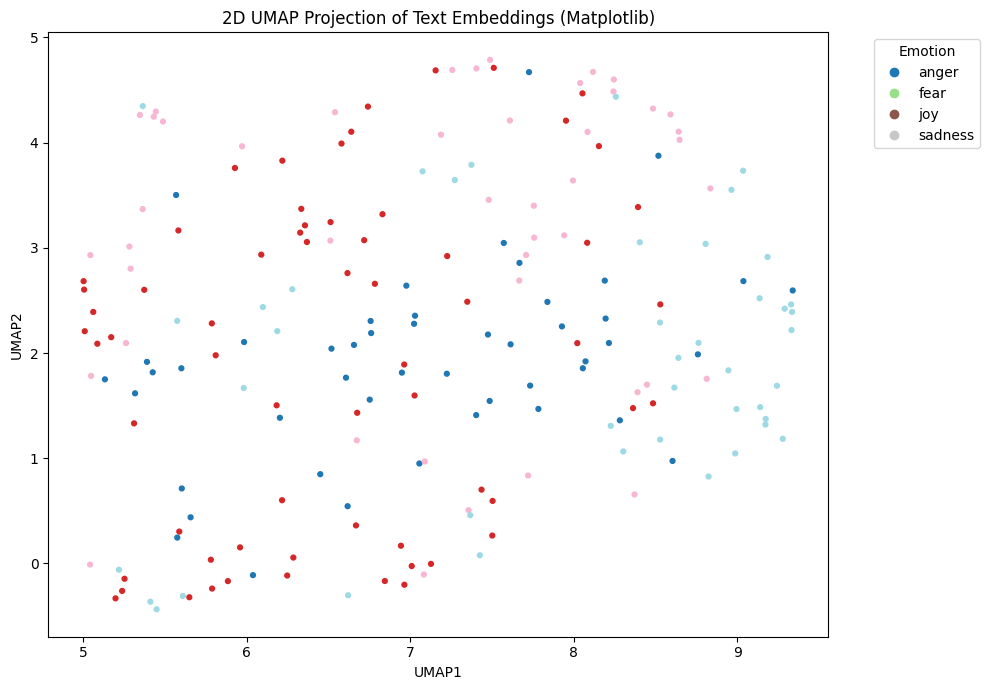

In [ ]:
import pandas as pd
import numpy as np
import umap.umap_ as umap
import matplotlib.pyplot as plt


combined_df = pd.concat([train_df_new, test_df_new], ignore_index=True)


X_embeddings = np.array(combined_df['embeddings_values'].tolist())


reducer = umap.UMAP(n_components=2, metric='cosine', random_state=28)
embedding_2d = reducer.fit_transform(X_embeddings)


UMAP1 = embedding_2d[:, 0]
UMAP2 = embedding_2d[:, 1]
emotion = combined_df['emotion']


unique_labels = emotion.unique()
color_map = {label: i for i, label in enumerate(unique_labels)}
colors = [color_map[e] for e in emotion]


plt.figure(figsize=(10, 7))
scatter = plt.scatter(UMAP1, UMAP2, c=colors, cmap="tab20", s=12)


handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=scatter.cmap(color_map[label]/len(unique_labels)))
    for label in unique_labels
]
plt.legend(handles, unique_labels, title="Emotion", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("2D UMAP Projection of Text Embeddings (Matplotlib)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()


We can see that even with Gemini's embeddings there doesn't seem to be a clear 2D separation of clusters with our data classes. It could be because emotions are often not discrete. Texts can contain mixed feelings (e.g., "bittersweet") or use similar language to express different emotions, causing their embeddings to be naturally close in semantic space. And also the process of projecting high-dimensional embeddings down to a 2D visualization inevitably loses some information, which can make distinct clusters appear to overlap.

---
##### <a id='toc1_5_8_1_1_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)

Apply UMAP to the same embeddings to reduce the dimensionality to 3D vectors and plot the 3D graph, discuss the differences and similarities with the 2D graph.

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



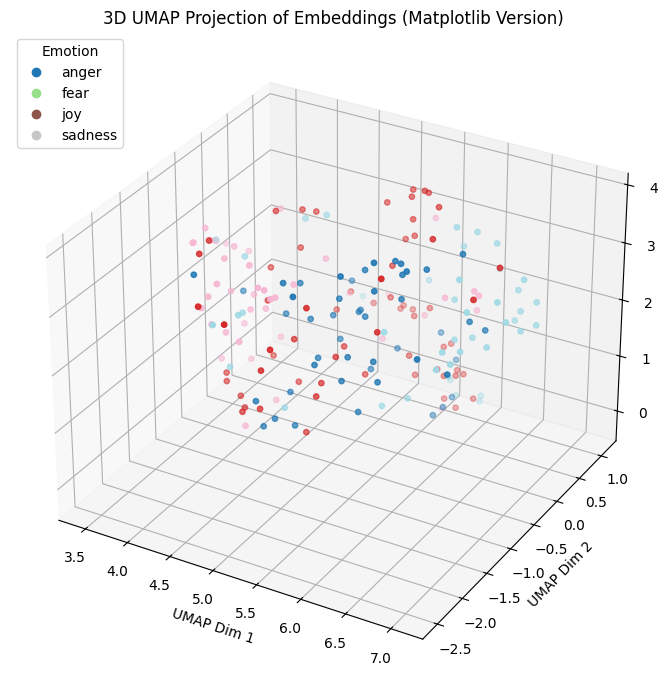

In [ ]:

import numpy as np
import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   


embed_array = np.array(combined_df["embeddings_values"].tolist())


umap_reducer_3d = umap.UMAP(
    n_components=3,
    metric="cosine",
    n_neighbors=15,
    min_dist=0.1,
    random_state=28
)


umap_result_3d = umap_reducer_3d.fit_transform(embed_array)


plot_df_3d = pd.DataFrame(umap_result_3d, columns=["AX1", "AX2", "AX3"])
plot_df_3d["emotion"] = combined_df["emotion"].values


unique_emotions = plot_df_3d["emotion"].unique()
color_map = {emo: idx for idx, emo in enumerate(unique_emotions)}
colors = [color_map[e] for e in plot_df_3d["emotion"]]


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    plot_df_3d["AX1"], 
    plot_df_3d["AX2"], 
    plot_df_3d["AX3"],
    c=colors, 
    cmap="tab20",
    s=15
)


legend_handles = [
    plt.Line2D([], [], marker='o', linestyle='', 
               color=sc.cmap(color_map[e] / len(unique_emotions)))
    for e in unique_emotions
]

ax.legend(legend_handles, unique_emotions, title="Emotion", loc="upper left")

ax.set_title("3D UMAP Projection of Embeddings (Matplotlib Version)")
ax.set_xlabel("UMAP Dim 1")
ax.set_ylabel("UMAP Dim 2")
ax.set_zlabel("UMAP Dim 3")

plt.tight_layout()
plt.show()


In [3]:
'''在 3D UMAP 的投影中，不同情緒的群集依然保持與 2D 圖相似的分群結構，但因為多了第三個維度，資料點之間的距離與層次關係呈現得更立體，也更容易分辨部分在 2D 
中重疊的樣本。此外，3D 視覺化能揭露一些 2D 空間中被壓縮掉的細節，但整體的群集形狀與分布趨勢仍與 2D 保持一致。'''

'在 3D UMAP 的投影中，不同情緒的群集依然保持與 2D 圖相似的分群結構，但因為多了第三個維度，資料點之間的距離與層次關係呈現得更立體，也更容易分辨部分在 2D \n中重疊的樣本。此外，3D 視覺化能揭露一些 2D 空間中被壓縮掉的細節，但整體的群集形狀與分布趨勢仍與 2D 保持一致。'

---
### <a id='toc1_5_9_'></a>[**2.5 Retrieval-Augmented Generation (RAG)**](#toc0_)

`NOTE: This whole section including the exercise is now considered a bonus section, not counted for the main grade.`

RAG (Retrieval-Augmented Generation) is a technique where a language model combines document retrieval with text generation. In RAG, a retrieval system first finds relevant documents or text chunks, and then the language model uses this retrieved information to generate a more informed and accurate response. This method enhances the model's ability to answer questions by grounding its responses in real, external data.

In the following code, we will load a webpage as a document, which allows us to retrieve text from a URL. After loading the content, we will split the document into smaller, manageable chunks, making it easier for our model to process. Then, we'll generate embeddings for these chunks with a specified LLM model (Gemini Embedding Model). These embeddings will be stored in a vector database, which enables us to perform similarity searches. By setting up this retrieval system, we can use a RAG chain to answer questions. The retriever finds relevant text chunks from the document based on a query, and the LLM generates a response by incorporating this retrieved information, making the answers more grounded and accurate.

In this example we use the library langchain, for documentation on more functions of the library you can check the following link: [LangChain Tutorials](https://python.langchain.com/docs/tutorials/)

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Function to load, split, and retrieve documents
def load_and_retrieve_docs(url):
    loader = WebBaseLoader(
        web_paths=(url,),
        bs_kwargs=dict() 
    ) 
    docs = loader.load() #We will load the URL that will serve as our data source
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150) #We will divide the URL in chunks of text for easier comparison in the vector space
    splits = text_splitter.split_documents(docs)
    #print(splits) #You can print this to see how the chunks in the url where split
    embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
    vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings) #Our vector space for comparison
    return vectorstore.as_retriever()


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) #Format the retrieved docs in an orderly manner for prompting

# Define the Gemini LLM function
def gemini_llm(question, context):
    system_prompt = "You are a RAG Agent that needs to provide a well structured answer based on the provided question and context."
    formatted_prompt = f"Question: {question}\n\nContext: {context}"
    response, logs = prompt_gemini(input_prompt = formatted_prompt, system_instruction = system_prompt, with_tokens_info = True)
    print(f"logs: \n{logs}")
    # print(f"Retrieved context: \n{context}\n\n") # You can print this to observe the retrieved context
    return response


# Define the RAG chain
def rag_chain(question, retriever):
    retrieved_docs = retriever.invoke(question)
    formatted_context = format_docs(retrieved_docs)
    return gemini_llm(question, formatted_context)


In [ ]:
url="https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/"
# Create the retriever
retriever = load_and_retrieve_docs(url)

# Use the RAG chain
result = rag_chain(question="What are the Key Challenges in Realizing AGI’s Full Potential", retriever=retriever)
display(Markdown(result))


##### <a id='toc1_5_9_1_1_'></a>[**Actual answer in the URL:**](#toc0_)

![pic11.png](pics/pic11.png)

##### <a id='toc1_5_9_1_2_'></a>[**Content in the URL that might get into the generated answer because of similar semantic meaning:**](#toc0_)

![pic12.png](pics/pic12.png)

source: https://qbotica.com/understanding-artificial-general-intelligence-agi-an-in-depth-overview/


---
##### <a id='toc1_5_9_1_3_'></a>[**>>> Bonus Exercise 5 (Take home):**](#toc0_)

`NOTE: This exercise is now considered a bonus one, not counted for the main grade, only as extra points.`

Your task is to test the RAG system with your own chosen URL and analyze its performance.

1. Find a URL of a webpage with interesting text content to test the RAG pipeline.
2. Make a question about the content in the webpage you chose.
3. Discuss how good the question was answered by the model, if the model missed important information related to your question.
4. Display a screenshot of the real answer in the webpage.

In [ ]:
!pip install langchain-community langchain-text-splitters chromadb sentence-transformers

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from IPython.display import Markdown

def load_and_retrieve_docs(url):

    
    loader = WebBaseLoader(web_paths=(url,), bs_kwargs=dict())
    docs = loader.load()

    
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150
    )
    splits = splitter.split_documents(docs)

    
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

    
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=embeddings
    )

    return vectorstore.as_retriever()



url = "https://qbotica.com/newsroom/qbotica-achieves-platinum-level-partner-status-with-uipath-for-intelligent-automation-solutions/"
retriever = load_and_retrieve_docs(url)


result = rag_chain(
    question="With what company does Ubotica achieve platinum level partner with?",
    retriever=retriever
)

display(Markdown(result))


'pip' ���O�����Υ~���R�O�B�i���檺�{���Χ妸�ɡC
C:\Users\USER\AppData\Local\Temp\ipykernel_55128\2450692171.py:23: LangChainDeprecationWarning:

The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.



ImportError: Could not import sentence_transformers python package. Please install it with `pip install sentence-transformers`.

---
### <a id='toc1_5_10_'></a>[**2.6 Few-Shot Prompting Classification:**](#toc0_)

Few-shot prompting is a technique where a Large Language Model (LLM) is given a small number of labeled examples within a prompt to guide its classification. This allows the model to perform a new task with minimal data, avoiding the need for extensive fine-tuning.

In this lab, we will use the Gemini API to perform zero-shot, 1-shot, and 5-shot emotion classification:

*   **Zero-shot:** The model classifies text without any prior examples.
*   **1-shot:** The model is given one example for each emotion before classifying.
*   **5-shot:** The model is given five examples per emotion for better context.

To make our implementation robust and efficient, we are incorporating two key features:

1.  **Structured Output:** We provide the Gemini model with a specific output schema (`Emotions` class). This instructs the model to return *only* a valid emotion label (e.g., `joy`), which makes the output predictable and reliable, minimizing errors.
2.  **API Rate Handling:** The code includes a function to manage the requests-per-minute limit of the Gemini API.

We will test the model's performance on a small sample of 20 texts per emotion to ensure the process runs quickly. If the model provides an invalid response, the code will automatically retry the request until a valid classification is received.

**Prompt Structure:**
`System Instruction -> Task Description -> Examples (if not zero-shot) -> Text to Classify`


<span style="color:green">For the exercises in this section there is no need to re-run the cells, you can use the data that has been saved previously to the corresponding directory.</span>

In [87]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import enum
import os
from tqdm import tqdm
import json
import time
# Define the emotion labels
emotions = ['anger', 'fear', 'joy', 'sadness']
# Define the model to use for few-shot prompting

# Schema for the output, the type enum can be used to make a pool of options if what we want is to classify our text selecting only one of them
class Emotions(enum.StrEnum):
    ANGER = 'anger'
    FEAR = 'fear'
    JOY = 'joy'
    SADNESS = 'sadness'


# Function to handle the rate limits of gemini models
def handle_rate_limit(request_count, first_request_time, max_calls_per_min):
    current_time = time.time()

    # Initialize timer on the first request of a new window
    if request_count == 0:
        first_request_time = current_time

    request_count += 1

    # If the rate limit is reached
    if request_count > max_calls_per_min:
        elapsed_time = current_time - first_request_time
        if elapsed_time < 60:
            wait_time = 60 - elapsed_time
            print(f"Rate limit of {max_calls_per_min} requests per minute reached. Waiting for {wait_time:.2f} seconds.")
            time.sleep(wait_time)

        # Reset for the new window
        request_count = 1
        first_request_time = time.time()
    
    return request_count, first_request_time, max_calls_per_min

# Function to sample examples per emotion category
def sample_few_shots(df, emotions, num_samples=5):
    few_shot_examples = {}
    for emotion in emotions:
        few_shot_examples[emotion] = df[df['emotion'] == emotion].sample(n=num_samples, random_state=42)
    return few_shot_examples

# Function to build the prompt based on the number of examples (few-shot, 1-shot, zero-shot)
def build_prompt(examples, emotions, num_shots=5):
    classification_instructions = """
You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    """
    
    prompt = classification_instructions + "\n\n"
    
    if num_shots > 0:
        prompt += f"Examples: \n"
        for emotion in emotions:
            for _, row in examples[emotion].iterrows():
                prompt += f"Text: {row['text']}\nClass: {emotion}\n\n" #Show the examples in the same format it will be shown for the classification text
                if num_shots == 1:  # If 1-shot, break after the first example for each emotion
                    break
    return prompt

# Function to classify using the LLM with retry for incorrect responses
def classify_with_llm(test_text, prompt_base, system_prompt, classes, schema):
    response = None
    while not response or response not in classes:
        full_prompt = f"{prompt_base}\nClassification:\nText: {test_text}\nClass: " #The classification text will leave the emotion label to be filled in by the LLM
        try:
            result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt)
            # print(f"result: {result} \n")
            # print(f"type: {type(result)}")
            if not result:
                # In case of giving empty responses with temperature 0.0, we set a higher temperature to seek for different responses
                result = prompt_gemini(input_prompt = [full_prompt], schema = schema, system_instruction = system_prompt, temperature=1.0)

            try:
                # If the result is in the correct format it can be parsed using json
                response = json.load(result)
            except:
                # In case it's not in a json friendly format
                # Deleting characters " and ' in case they appear in our response with the class of the text 
                response = result.replace('"', '')    
                response = response.replace("'", "")  

                
        # except exceptions.ResourceExhausted as e:
        except Exception as e:
            print(f"Waiting to retry... Error: {e}")
            time.sleep(15)
            print(f"test_text: {test_text}")
            return classify_with_llm(test_text, prompt_base, system_prompt, classes, schema) # Retry the request


        if response not in classes:  # Retry if not a valid response
            print(f"Invalid response: {response}. Asking for reclassification.")
    return response

# Main function to run the experiment with the option for zero-shot, 1-shot, or 5-shot prompting
def run_experiment(df_train, df_test, num_test_samples=5, num_shots=5):
    # Sample examples for few-shot prompting based on num_shots
    if num_shots > 0:
        few_shot_examples = sample_few_shots(df_train, emotions, num_samples=num_shots) 
        prompt_base = build_prompt(few_shot_examples, emotions, num_shots=num_shots)
    else:
        prompt_base = build_prompt(None, emotions, num_shots=0)  # Zero-shot has no examples

    # System prompt for our classification model:
    system_prompt = "You are an emotion classification model for text data. Do not give empty responses, classify according to the list of possible classes."

    # Prepare to classify the test set
    results_data = []

    print(prompt_base)
    # Sample 20 examples per emotion for the test set to classify
    test_samples = sample_few_shots(df_test, emotions, num_samples=num_test_samples)

    # Variables to handle rate limit of gemini
    request_count = 0
    max_calls_per_min = 15 # Gemini 2.5 Flash Lite has this maximum set in the documentation
    first_request_time = None

    # Classify 20 test examples (5 from each category) and save predictions
    for emotion in emotions:
        for _, test_row in tqdm(test_samples[emotion].iterrows(), desc=f"Processing samples for emotion: {emotion}...", total=num_test_samples):
            test_text = test_row['text']
            request_count, first_request_time, max_calls_per_min = handle_rate_limit(request_count, first_request_time, max_calls_per_min)  # Check and handle rate limit before each API call
            predicted_emotion = classify_with_llm(test_text = test_text, prompt_base = prompt_base, system_prompt = system_prompt, classes = emotions, schema = Emotions)
            # Append the results data:
            results_data.append({
                    'text': test_text,
                    'true_emotion': emotion,
                    'predicted_emotion': predicted_emotion
                })

    # Create dataframe to save the results data
    results_df = pd.DataFrame(results_data)
    
    # Extract just the true and predicted labels for metrics calculations
    true_labels = results_df['true_emotion']
    predictions = results_df['predicted_emotion']

    output_dir = "./results/llm_classification_results"
    os.makedirs(output_dir, exist_ok=True)
    # Save the results
    filename = f"{output_dir}/results_samples_{num_test_samples}_shots_{num_shots}.csv"
    
    # Save the DataFrame to CSV
    results_df.to_csv(filename, index=False)
    print(f"\nResults saved to {filename}")

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    
    # Classification report
    print(classification_report(y_true=true_labels, y_pred=predictions))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true=true_labels, y_pred=predictions) 
    my_tags = ['anger', 'fear', 'joy', 'sadness']
    plot_confusion_matrix(cm, classes=my_tags, title=f'Confusion matrix for classification with \n{num_shots}-shot prompting')

**Important: The next part should take around 16 minutes to finish running due to API Rate Limits**

**Note:** You might see an `429 RESOURCE_EXHAUSTED` error when running the following code all at once, this is because the `current API Rate Limit handling cannot reliably find out how many requests we have left per minute` from cell to cell, there is no Gemini feature created for it to get the information from their servers. So, `if you don't want to see the error you can just wait 1 minute` after one cell finished processing. But `even if there is an error showing it is fine`, internally in the code `there is a retry that happens every 15 seconds` until we finish processing our sampled data. `The lab is designed to never reach the total rate limit per day quota.`

In [ ]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with zero-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=0)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Wont use using @mothercareuk @Mothercarehelp again!! These guys cant get nothing right!! #fuming
Class: anger

Text: Do you think humans have the sense for recognizing impending doom? 
Class: fear

Text: My future must be bright af.
Class: joy

Text: @LazyBoiSam blues... blues? 🤔
Class: sadness




Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:12<00:03,  1.33it/s]

Rate limit of 15 requests per minute reached. Waiting for 47.89 seconds.


Processing samples for emotion: fear...:  50%|█████     | 10/20 [00:07<00:07,  1.42it/s]

Rate limit of 15 requests per minute reached. Waiting for 49.28 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 49.92 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [00:11<00:03,  1.38it/s]

Rate limit of 15 requests per minute reached. Waiting for 48.24 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:03<00:00,  3.18s/it]



Results saved to ./llm_classification_results/results_samples_20_shots_1.csv
Accuracy: 55.00%
              precision    recall  f1-score   support

       anger       0.52      0.60      0.56        20
        fear       0.71      0.25      0.37        20
         joy       0.56      0.75      0.64        20
     sadness       0.52      0.60      0.56        20

    accuracy                           0.55        80
   macro avg       0.58      0.55      0.53        80
weighted avg       0.58      0.55      0.53        80



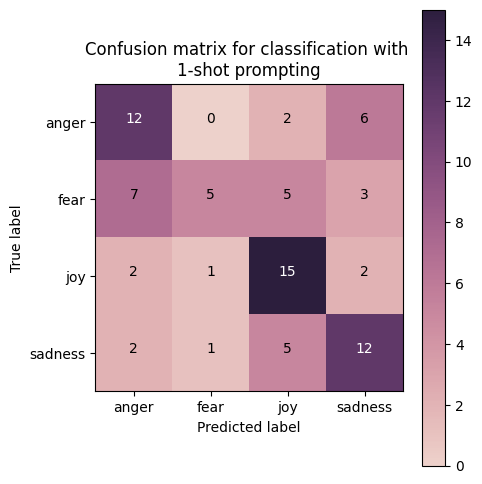

In [ ]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 1-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=1)


You will be given a text extracted from social media and your task is to classify the text into one of the following emotion categories: 
"anger" | "fear" | "joy" | "sadness"
    

Examples: 
Text: Wont use using @mothercareuk @Mothercarehelp again!! These guys cant get nothing right!! #fuming
Class: anger

Text: If you be #angry, which may be the case, &amp; which may be unavoidable, see that the sudden excitement does not become sin. #AlbertBarnes
Class: anger

Text: @cc_yandian @HillaryClinton her team must draw from a hat for daily personality #drugged  #yeller #quiet #screamer #😂😂
Class: anger

Text: I believe women are more fiery because once a month they go through struggle and struggle is what develops a strong character.
Class: anger

Text: I don't mean to offend anyone, but 93.7 literally blames everything on white people. In some cases it's true, but a lot of times, it's not
Class: anger

Text: Do you think humans have the sense for recognizing impending doom? 
Class: fear


Processing samples for emotion: anger...:  75%|███████▌  | 15/20 [00:11<00:03,  1.28it/s]

Rate limit of 15 requests per minute reached. Waiting for 48.21 seconds.


Processing samples for emotion: fear...:  50%|█████     | 10/20 [00:07<00:07,  1.31it/s]

Rate limit of 15 requests per minute reached. Waiting for 48.51 seconds.


...

Rate limit of 15 requests per minute reached. Waiting for 48.22 seconds.


Processing samples for emotion: sadness...:  75%|███████▌  | 15/20 [01:00<00:04,  1.09it/s]

Rate limit of 15 requests per minute reached. Waiting for 47.81 seconds.


Processing samples for emotion: sadness...: 100%|██████████| 20/20 [01:51<00:00,  5.59s/it]



Results saved to ./llm_classification_results/results_samples_20_shots_5.csv
Accuracy: 56.25%
              precision    recall  f1-score   support

       anger       0.56      0.70      0.62        20
        fear       0.67      0.20      0.31        20
         joy       0.62      0.65      0.63        20
     sadness       0.50      0.70      0.58        20

    accuracy                           0.56        80
   macro avg       0.59      0.56      0.54        80
weighted avg       0.59      0.56      0.54        80



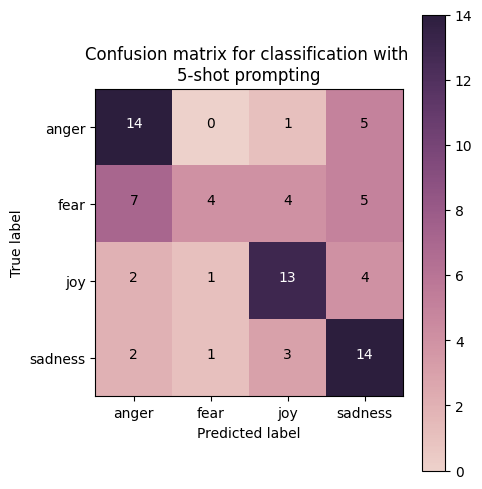

In [ ]:
# If you see '429 RESOURCE_EXHAUSTED' errors it's fine, wait until the data gets processed, it will keep retrying until it finishes

# Example of running the experiment with 5-shot prompting
run_experiment(train_df, test_df, num_test_samples=20, num_shots=5)

---
##### <a id='toc1_5_10_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Compare and discuss the overall results of the zero-shot, 1-shot and 5-shot classification.

In [ ]:
# Answer here
'''
在理論上，zero-shot 因為沒有提供任何事例，所以通常準確率最低；1-shot 與 5-shot 因為提供了更多範例，應能讓模型更容易掌握分類方向，其中 5-shot 通常會表現最佳。

不過在本次實驗中，結果反而呈現：

1-shot > zero-shot > 5-shot


我推測原因有包括：

資料量太少導致 5-shot 過擬合：範例越多，模型反而容易記住示例特徵，降低泛化能力。

示例品質與一致性不足：五個示例之間可能差異大，造成模型判斷混亂。

1-shot 提供最乾淨的訊號：單一示例反而能明確告訴模型任務需求，不會引入額外雜訊。

因此，本次的結果顯示：few-shot 的效果不僅取決於示例數量，也受到示例品質與任務資料量的影響。
'''

---
##### <a id='toc1_5_10_1_2_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

**Case Study:** Check the results' files inside the `results/llm_classification_results` directory and find cases where the **text classification improves with more examples** (pred emotion is right with examples), **cases where it does not improve** (pred emotion always wrong) and **cases where the classification got worse with more examples** (pred emotion goes from right to wrong with examples). For this you need to load the results with pandas and handle the data using its dataframe functions. Discuss about the findings.

In [ ]:
# Answer here
# Answer here
import pandas as pd


df_0shot = pd.read_csv(r'C:\Users\USER\Downloads\DM2025-Lab2-Exercise-main\DM2025-Lab2-Exercise-main\results\llm_classification_results\results_samples_20_shots_0.csv')
df_1shot = pd.read_csv(r'C:\Users\USER\Downloads\DM2025-Lab2-Exercise-main\DM2025-Lab2-Exercise-main\results\llm_classification_results\results_samples_20_shots_1.csv')
df_5shot = pd.read_csv(r'C:\Users\USER\Downloads\DM2025-Lab2-Exercise-main\DM2025-Lab2-Exercise-main\results\llm_classification_results\results_samples_20_shots_5.csv')


df_0shot


,text,true_emotion,predicted_emotion
0,@CozanGaming that's what lisa asked before she...,anger,joy
1,@isthataspider @dhodgs i will fight this guy! ...,anger,anger
2,"[ @HedgehogDylan ] *she would frown a bit, fol...",anger,anger
3,@TrueAggieFan oh so that's where Brian was! Wh...,anger,anger
4,Just joined #pottermore and was sorted into HU...,anger,anger
...,...,...,...
75,watching this uni reveal is so depressing i mi...,sadness,sadness
76,and for inconsolable Oxford academics - 'Bruss...,sadness,anger
77,“Dyslexia is the affliction of a frozen genius...,sadness,sadness
78,amateur author Twitter might be the most depre...,sadness,sadness


In [ ]:

print("0-shot classification results:")

df_0shot["correct"] = df_0shot["true_emotion"] == df_0shot["predicted_emotion"]


print(df_0shot.groupby("true_emotion")["correct"].value_counts())


print(df_0shot.groupby("true_emotion")["correct"].mean())


0-shot classification results:
true_emotion  correct
anger         True       12
              False       8
fear          False      17
              True        3
joy           True       17
              False       3
sadness       False      12
              True        8
Name: count, dtype: int64
true_emotion
anger      0.60
fear       0.15
joy        0.85
sadness    0.40
Name: correct, dtype: float64


In [ ]:

print("1-shot classification results:")

df_1shot["correct"] = df_1shot["true_emotion"] == df_1shot["predicted_emotion"]


print(df_1shot.groupby("true_emotion")["correct"].value_counts())


print(df_1shot.groupby("true_emotion")["correct"].mean())


1-shot classification results:
true_emotion  correct
anger         True       12
              False       8
fear          False      15
              True        5
joy           True       15
              False       5
sadness       True       12
              False       8
Name: count, dtype: int64
true_emotion
anger      0.60
fear       0.25
joy        0.75
sadness    0.60
Name: correct, dtype: float64


In [ ]:

print("5-shot classification results:")

df_5shot["correct"] = df_5shot["true_emotion"] == df_5shot["predicted_emotion"]
df_5shotCorrecArr = df_5shot["correct"].values  


print(df_5shot.groupby("true_emotion")["correct"].value_counts())


print(df_5shot.groupby("true_emotion")["correct"].mean())


5-shot classification results:
true_emotion  correct
anger         True       14
              False       6
fear          False      16
              True        4
joy           True       13
              False       7
sadness       True       14
              False       6
Name: count, dtype: int64
true_emotion
anger      0.70
fear       0.20
joy        0.65
sadness    0.70
Name: correct, dtype: float64


In [ ]:


comparison_df = df_5shot[['text', 'true_emotion']].copy()
comparison_df['0-shot_correct'] = df_0shot['correct']
comparison_df['1-shot_correct'] = df_1shot['correct']
comparison_df['5-shot_correct'] = df_5shot['correct']


print(comparison_df.to_string())


                                                                                                                                                text true_emotion  0-shot_correct  1-shot_correct  5-shot_correct
0                                                         @CozanGaming that's what lisa asked before she started raging at me, 'can I call you?' heh        anger           False           False            True
1       @isthataspider @dhodgs i will fight this guy! Don't insult the lions like that! But seriously they kinda are.Wasted some of the best players        anger            True            True            True
2         [ @HedgehogDylan ] *she would frown a bit, folding her arms* 'why is it that every time I'm in need of assistance someone expects a lil **        anger            True           False           False
3                                                                         @TrueAggieFan oh so that's where Brian was! Where was my invite? #offended        ange

In [ ]:
# 從結果中可以看到，有些句子在增加 shot 之後反而變得更糟。
# 例如：
# "Imagine how sad LA fans are gonna be when they get eliminated..."
# 正確情緒是 sadness，0-shot 判對，但 1-shot 和 5-shot 都判錯。
# 這說明 few-shot prompting 並不是 shot 越多就一定越準。

# 但也有反例：像 example ID 9 的
# "The rage has died down"
# 正確情緒是 anger，0-shot 判錯，但 1-shot、5-shot 都能判對。
# 代表在某些情況下，加一些示例確實能幫助模型捕捉語意。

# 另外，還有一些句子三種 prompting 都無法正確分類，例如：
# "@soozclifford ... Motlop/Cowan #timid"
# 正確情緒是 fear，但三種方法全部都判錯。
# 這類句子的語氣不明顯、情緒線索較模糊，因此模型整體都難以判斷。

# 總結來說：
# 有些例子會因增加示例而提升分類正確率
# 有些例子則完全沒有改善
# 甚至有例子因為示例干擾而變得更差
# 因此 few-shot prompting 的效果高度依賴文本本身，並不是一個固定「越多越好」的線性關係。

---
### <a id='toc1_5_11_'></a>[**2.7 Extra LLM Related Materials:**](#toc0_)
So this will be it for the lab, but here are some extra materials if you would like to explore:

- **How to use OpenAI ChatGPT model's API (Not Free API):** [Basics Video](https://www.youtube.com/watch?v=e9P7FLi5Zy8), [Basics GitHub](https://github.com/gkamradt/langchain-tutorials/blob/main/chatapi/ChatAPI%20%2B%20LangChain%20Basics.ipynb), [RAG's Basics Video](https://www.youtube.com/watch?v=9AXP7tCI9PI&t=300s), [RAG's Basics GitHub](https://github.com/techleadhd/chatgpt-retrieval)

- **Advanced topic - QLoRA (Quantized Low-Rank Adapter):** QLoRA is a method used to make fine-tuning large language models more efficient. It works by adding a small, trainable part (LoRA) to a pre-trained model, while keeping the rest of the model frozen. At the same time, it reduces the size of the model’s data using a process called quantization, which makes the model require less memory. This allows you to fine-tune large models without needing as much computational power, making it easier to adapt models for specific tasks. Materials: [Paper GitHub](https://github.com/artidoro/qlora?tab=readme-ov-file), [Llama 3 Application Video](https://www.youtube.com/watch?v=YJNbgusTSF0&t=512s),[Llama 3 Application GitHub](https://github.com/adidror005/youtube-videos/blob/main/LLAMA_3_Fine_Tuning_for_Sequence_Classification_Actual_Video.ipynb)

- **How to Fine-tune and run local LLMs with the `unsloth` library:** [unsloth tutorials](https://docs.unsloth.ai/models/tutorials-how-to-fine-tune-and-run-llms)

- **Google's Agent Development Kit Documentation:** [ADK](https://google.github.io/adk-docs/)

- **Build AI agents with LangGraph:** [LangGraph Documentation](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)

---